# Lab 1

## a)

In [1]:
def tokenize_text(text):
    if not text or not text.strip():
        return []
    
    tokens = []
    i = 0
    current_token = ""
    
    while i < len(text):
        char = text[i]
        if char.isspace():
            if current_token:
                tokens.append(normalize_token(current_token))
                current_token = ""
            i += 1
            continue
        if char == '.' and is_decimal_point(text,i,current_token):
            current_token += char
            i += 1
            continue
        if not char.isalnum():
            if current_token:
                tokens.append(normalize_token(current_token))
                current_token = ""
            tokens.append(char)
            i += 1
            continue
        current_token += char
        i += 1
    
    if current_token:
        tokens.append(normalize_token(current_token))
    
    return tokens
def is_numeric(token):
    if '.' in token:
        parts = token.split('.')
        if len(parts)==2 and parts[0].isdigit() and parts[1].isdigit():
            return True
    
    return token.isdigit()
def is_decimal_point(text,pos,current_token):
    if not current_token or not current_token[-1].isdigit():
        return False
    
    if pos < len(text)-1 and text[pos+1].isdigit():
        return True
    
    return False

def normalize_token(token):
    if not token:
        return token
    if is_numeric(token):
        return token
    if any(c.isalpha() for c in token):
        return token.lower()

    return token

Use whitespace to separate tokens. Check if a '.' is a decimal point nd act accordingly. Normalize a token, lowercase alphabetic parts, keep numbers as is. My initial approach separated decimal numbers but this approach doesn't do that.

In [2]:
def process_tokens_file():
    with open('tokens.txt', 'r', encoding='utf-8') as file:
        lines = []
        for i, line in enumerate(file):
            if i >= 10:
                break
            lines.append(line.rstrip('\n\r'))
    
    for i, line in enumerate(lines, 1):
        if line.strip():
            tokens = tokenize_text(line)
            print(f"Line {i}:")
            print(f"{tokens}")
            print("\n")

In [3]:
process_tokens_file()

Line 1:
['russian', 'for', 'plastic', 'bag', 'is', 'полиэтиленовый', 'пакет', '.', '7.3', 'out', 'of', '10', 'statistics', 'is', 'made', 'up', '.', 'i', 'do', 'not', 'like', 'green', 'eggs', 'and', 'ham', '.', 'i', 'do']


Line 2:
['not', 'like', 'them', 'sam', '-', 'i', '-', 'am', '.', 'dr', '.', 'mulholland', 'lives', 'on', 'mulholland', 'dr', '.', 'in', 'hollywood', '.', '1', ',', '2', ',', '3', '.', '.', '.', 'slashdot', '.', 'com', 'has', 'some', 'interesting']


Line 3:
['articles', '.', 'i', "'", 'm', 'going', 'to', 'update', 'my', 'resumé', '.', 'j', '.', 'h', '.', 'u', '.', 'has', 'a', 'great', 'la', '-', 'crosse', 'team', '.', 'born', 'in', 'the', 'u', '.', 's', '.', 'of', 'a', '.', 'incorrect', 'plurala', 'can', 'be']


Line 4:
['fun', '.', 'is', 'capitalization', '(', 'sp', '?', ')', 'truly', 'necessary', '?', 'i', 'think', 'lower', 'case', 'is', 'more', 'legible', '.', 'when', 'people', 'write', 'in', 'all', 'caps', ',', 'it', 'feels']


Line 5:
['like', 'they', "'", 're',

The results first ten lines of the tokens.txt are shown above.

## b)

In [4]:
def process_tokens_file_stats():
    token_counts = {} 
    total_tokens = 0
    line_count = 0
    with open('tokens.txt', 'r', encoding='utf-8') as file:
        for line in file:
            line = line.rstrip('\n\r')
            if line.strip():
                line_count += 1
                tokens = tokenize_text(line)
                for token in tokens:
                    total_tokens += 1
                    token_counts[token] = token_counts.get(token, 0) + 1
    
    sorted_tokens = sorted(token_counts.items(), key=lambda x: x[1], reverse=True)
    
    vocab_size = len(token_counts)
    
    singletons = sum(1 for count in token_counts.values() if count == 1)
    singleton_percentage = (singletons / vocab_size) * 100 if vocab_size > 0 else 0
    
    print(f"{line_count} Number of lines")
    print(f"{vocab_size} Number of unique tokens (vocabulary size)")
    print(f"{total_tokens} Number of tokens (collection size)")
    
    ranks = [1, 2, 3, 4,5,100,500,1000,5000,10000]
    
    for rank in ranks:
        if rank <= len(sorted_tokens):
            token, count = sorted_tokens[rank-1]
            if rank <= 5:
                print(f"{rank}. {token} {count}")
            elif rank == 100:
                print("...")
                print(f"{rank}. {token} {count}")
            else:
                print(f"{rank}. {token} {count}")
    
    print(f"{singletons} Number of singleton terms")
    print(f"{singleton_percentage:.3f}% Percentage of singletons")
    
    return {'line_count': line_count,'vocab_size': vocab_size,'total_tokens': total_tokens,'token_counts': token_counts,'sorted_tokens': sorted_tokens,'singletons': singletons,'singleton_percentage': singleton_percentage}


In [5]:
stats = process_tokens_file_stats()

944802 Number of lines
282544 Number of unique tokens (vocabulary size)
23900302 Number of tokens (collection size)
1. the 1156385
2. . 1107674
3. , 1027875
4. to 566837
5. and 536551
...
100. only 22349
500. recent 4785
1000. additional 2530
5000. occupied 376
10000. rita 135
151554 Number of singleton terms
53.639% Percentage of singletons


## c)

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [7]:
def plot_zipf_analysis(stats_data):

    if not stats_data:
        print("No statistics data available for plotting.")
        return
    
    sorted_tokens = stats_data['sorted_tokens']
    
    ranks = list(range(1, len(sorted_tokens) + 1))
    frequencies = [count for token, count in sorted_tokens]
    
    plt.loglog(ranks, frequencies, 'b.', alpha=0.6, markersize=3, label='Actual Data')
    
    k = frequencies[0]
    theoretical_freq = [k / rank for rank in ranks]
    
    plt.loglog(ranks, theoretical_freq, 'r-', alpha=0.8, linewidth=2, label=f"Zipf's Law (k={k})")
    
    plt.xlabel('Rank (log scale)', fontsize=12)
    plt.ylabel('Frequency (log scale)', fontsize=12)
    plt.title('Zipf\'s Law Analysis: Frequency vs. Rank (Log-Log Plot)', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    log_ranks = np.log(ranks)
    log_frequencies = np.log(frequencies)
    correlation = np.corrcoef(log_ranks, log_frequencies)[0, 1]

    
    slope, intercept = np.polyfit(log_ranks, log_frequencies, 1)

    
    return {'correlation': correlation,'slope': slope,'intercept': intercept,'ranks': ranks,'frequencies': frequencies}

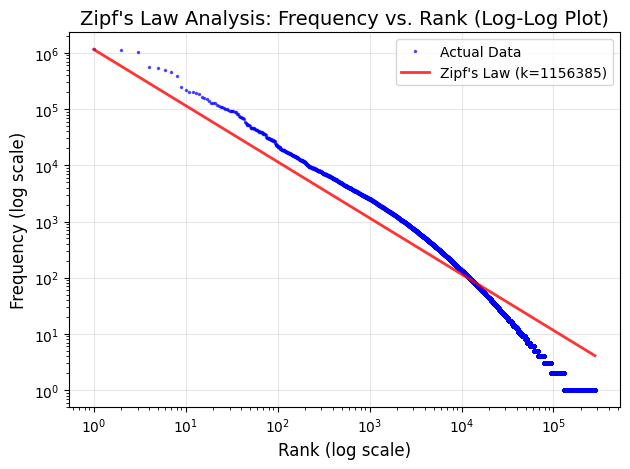

In [8]:
stats = plot_zipf_analysis(stats)

The data follows Zipf's as the plot shows that the two lines are very close together.

## d)

In [9]:
def detect_sentence_boundaries(line):
    if not line or not line.strip():
        return [0]
    abbreviations = {'dr', 'mr', 'mrs', 'ms', 'prof'}
    sentence_endings = []
    i = 0
    while i < len(line):
        char = line[i]
        if char in '.!?':
            is_sentence_end = True
            if char == '.':
                if (i > 0 and i < len(line) - 1 and 
                    line[i-1].isdigit() and line[i+1].isdigit()):
                    is_sentence_end = False
                elif i > 0:
                    word_start = i - 1
                    while word_start >= 0 and (line[word_start].isalnum() or line[word_start]=='.'):
                        word_start -= 1
                    word_start += 1
                    
                    if word_start < i:
                        word = line[word_start:i].lower().replace('.', '')
                        if word in abbreviations:
                            if i < len(line) - 1:
                                next_char = line[i+1]
                                if next_char.islower() or next_char=='.':
                                    is_sentence_end = False
                                elif (next_char.isspace() and i < len(line) - 2 and 
                                      line[i+2].islower()):
                                    is_sentence_end = False

            if char == '.' and i<len(line) - 1 and line[i + 1]=='.':
                while i < len(line)-1 and line[i+1]=='.':
                    i += 1
            
            if is_sentence_end:
                sentence_endings.append(i)
        i += 1
    
    if line and not line.rstrip()[-1] in '.!?':
        last_char_pos = len(line.rstrip()) - 1
        if last_char_pos >= 0:
            sentence_endings.append(last_char_pos)
    
    return [len(sentence_endings)]+sentence_endings



In [10]:
def process_sentence_file(filename):
    with open(filename,'r',encoding='utf-8') as file:
        with open("spohane1.txt","w") as fout:
            for line_num, line in enumerate(file, 1):
                line = line.rstrip('\n\r')
                if line.strip():
                    result = detect_sentence_boundaries(line)
                    fout.write(' '.join(map(str, result)))
                    fout.write("\n")

In [11]:
process_sentence_file('sentences.txt')

## e)

In [12]:
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    print("Downloading NLTK punkt tokenizer...")
    nltk.download('punkt')

In [13]:
def nltk_tokenize_text(text):
    if not text or not text.strip():
        return []
    
    tokens = word_tokenize(text)
    normalized_tokens = []
    for token in tokens:
        normalized_tokens.append(normalize_token(token))
    
    return normalized_tokens

In [14]:
def nltk_process_tokens_file():
    with open('tokens.txt','r', encoding='utf-8') as file:
        lines = []
        for i, line in enumerate(file):
            if i >= 10:
                break
            lines.append(line.rstrip('\n\r'))

    for i, line in enumerate(lines, 1):
        if line.strip():
            tokens = nltk_tokenize_text(line)
            print(f"Line {i}:")
            print(f"{tokens}")
            print(f"\n")


In [15]:
def nltk_process_sentence_file(filename):
    with open(filename, 'r', encoding='utf-8') as file:
        with open("nltkProcessedSentence.txt", "w") as fout:
            for line_num, line in enumerate(file, 1):
                line = line.rstrip('\n\r')
                if line.strip():
                    result = nltk_detect_sentence_boundaries(line)

                    fout.write(' '.join(map(str, result)))
                    fout.write("\n")


In [16]:
def nltk_detect_sentence_boundaries(line):
    if not line or not line.strip():
        return [0]
    
    sentences = sent_tokenize(line)
    if not sentences:
        return [0]
    
    sentence_endings = []
    current_pos = 0
    for sentence in sentences:
        sentence_start = line.find(sentence, current_pos)
        if sentence_start == -1:
            sentence_start = current_pos
        
        sentence_end= sentence_start+len(sentence) -1
        sentence_endings.append(sentence_end)
        
        current_pos=sentence_start+len(sentence)
    
    return [len(sentence_endings)]+sentence_endings

In [17]:
nltk_process_tokens_file()

Line 1:
['russian', 'for', 'plastic', 'bag', 'is', 'полиэтиленовый', 'пакет', '.', '7.3', 'out', 'of', '10', 'statistics', 'is', 'made', 'up', '.', 'i', 'do', 'not', 'like', 'green', 'eggs', 'and', 'ham.i', 'do']


Line 2:
['not', 'like', 'them', 'sam-i-am', '.', 'dr.', 'mulholland', 'lives', 'on', 'mulholland', 'dr.', 'in', 'hollywood', '.', '1', ',', '2', ',', '3', '...', 'slashdot.com', 'has', 'some', 'interesting']


Line 3:
['articles', '.', 'i', "'m", 'going', 'to', 'update', 'my', 'resumé', '.', 'j.h.u', '.', 'has', 'a', 'great', 'la-crosse', 'team', '.', 'born', 'in', 'the', 'u.s.', 'of', 'a', '.', 'incorrect', 'plurala', 'can', 'be']


Line 4:
['fun', '.', 'is', 'capitalization', '(', 'sp', '?', ')', 'truly', 'necessary', '?', 'i', 'think', 'lower', 'case', 'is', 'more', 'legible', '.', 'when', 'people', 'write', 'in', 'all', 'caps', ',', 'it', 'feels']


Line 5:
['like', 'they', "'re", 'yelling', '!', 'it', 'is', 'precisely', 'to', 'these', 'substances', 'that', 'the', 'so-ca

In [18]:
nltk_process_sentence_file('sentences.txt')

nltk compared to my code keeps '...' together where as my code makes it '.', '.', '.'. Nltk also keeps 'j.h.u' together while my code separates it into 'j', '.', 'h', '.', 'u'. Clearly Nltk performs better as it keeps things that don't need and shouldn't be separated. 

For the sentence processing, the nltk sentence detection detects sentences better than my method, for example, mine splits the following, 'LARKSPUR, Colo. (AP) — A man is', in two sentences from the period but in reality it shouldn't be split because it's an abbreviation. NLTK doesn't split the string up in two different sentences.